In [1]:
import sys
sys.path.append('/home/tianze/MLLM/HuatuoGPT-Vision')

from cli import HuatuoChatbot
import torch
from PIL import Image
import json
from tqdm import tqdm
from transformers import TextStreamer
import seaborn as sns
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import numpy as np
import random
import cv2
from matplotlib import patches

bot = HuatuoChatbot("FreedomIntelligence/HuatuoGPT-Vision-7B")

NUM_IMG_TOKENS = 576
PATCHES = 24
SIZE = (336, 336)
LAYERS = bot.model.config.num_hidden_layers

/home/tianze/MLLM/HuatuoGPT-Vision


/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2025-09-25 01:29:45,961] [INFO] [real_accelerator.py:161:get_accelerator] Setting ds_accelerator to cuda (auto detect)
loading from FreedomIntelligence/HuatuoGPT-Vision-7B


/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


loading from CLIP first. This should only be used at inference!!!
loading vision model from openai/clip-vit-large-patch14-336


/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages/torch/nn/modules/module.py:2025: UserWarning: for vision_model.embeddings.class_embedding: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages

In [2]:
def generate_attention_maps(question, image_path, layer):

    general_question = 'Write a general description of the image.'
    prompt = f"{question} Answer the question using a single word or phrase."
    general_prompt = f"{general_question} Answer the question using a single word or phrase."

    model_output, input_ids = bot.inference_with_attention_output(prompt,image_path)
    input_ids = input_ids[0].cpu()
    index = torch.where(input_ids==-200)[0]
    att_maps = model_output['attentions'][layer][0, :, -1, index:index+NUM_IMG_TOKENS].mean(dim=0).to(torch.float32).detach().cpu().numpy().reshape(PATCHES, PATCHES)

    model_output, input_ids = bot.inference_with_attention_output(general_prompt,image_path)
    input_ids = input_ids[0].cpu()
    index = torch.where(input_ids==-200)[0]
    general_att_maps = model_output['attentions'][layer][0, :, -1, index:index+NUM_IMG_TOKENS].mean(dim=0).to(torch.float32).detach().cpu().numpy().reshape(PATCHES, PATCHES)

    return att_maps, general_att_maps


def convert_bbox_after_padding_and_resize(bbox, original_size, resized_size):
    # bbox = (x_min, y_min, x_max, y_max)

    W_orig, H_orig = original_size
    W_new, H_new = resized_size

    # Compute padding offsets
    if W_orig > H_orig:
        pad_top = (W_orig - H_orig) // 2
        pad_left = 0
    elif H_orig > W_orig:
        pad_top = 0
        pad_left = (H_orig - W_orig) // 2
    else:
        pad_top = pad_left = 0

    W_pad, H_pad = max(W_orig, H_orig), max(W_orig, H_orig)

    # Shift bbox due to padding
    x_min, y_min, x_max, y_max = bbox
    x_min_pad = x_min + pad_left
    y_min_pad = y_min + pad_top
    x_max_pad = x_max + pad_left
    y_max_pad = y_max + pad_top

    # Scale from padded to resized
    scale_x = W_new / W_pad
    scale_y = H_new / H_pad

    x_min_new = x_min_pad * scale_x
    y_min_new = y_min_pad * scale_y
    x_max_new = x_max_pad * scale_x
    y_max_new = y_max_pad * scale_y

    return [x_min_new, y_min_new, x_max_new, y_max_new]


def normalize(img):
    return (img - img.min()) / (img.max() - img.min())


def expand2square(pil_img, background_color):
    width, height = pil_img.size
    if width == height:
        return pil_img
    elif width > height:
        result = Image.new(pil_img.mode, (width, width), background_color)
        result.paste(pil_img, (0, (width - height) // 2))
        return result
    else:
        result = Image.new(pil_img.mode, (height, height), background_color)
        result.paste(pil_img, ((height - width) // 2, 0))
        return result


def draw_bboxes(image_input, bboxes, name, thickness, folder):

    # image = image_input.numpy()
    image = np.array(image_input)

    if image.max() <= 1.0:
        image = (image * 255).astype(np.uint8)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Show image with viridis colormap
    ax.imshow(image, cmap='viridis')

    colors = ['red'] * len(bboxes)

    # Draw each bounding box
    for bbox, color in zip(bboxes, colors):
        x_min, y_min, x_max, y_max = bbox
        w = x_max - x_min
        h = y_max - y_min
        rect = patches.Rectangle((x_min, y_min), w, h, linewidth=thickness,
                                 edgecolor=color, facecolor='none')
        ax.add_patch(rect)

    ax.axis('off')
    plt.tight_layout()
    os.makedirs(os.path.join(folder, name), exist_ok=True)
    plt.savefig(os.path.join(folder, f"{name}/source.png"), bbox_inches='tight', pad_inches=0)


def draw_att_map(qs, image_path, layers, bboxes, name, thickness, folder):
    for layer in layers:
        att_map, general_att_map = generate_attention_maps(qs, image_path, layer=layer)
        att_map_scaled = normalize(torch.tensor(att_map / general_att_map))
        attn_over_image = torch.nn.functional.interpolate(
            att_map_scaled.unsqueeze(0).unsqueeze(0), 
            size=SIZE, 
            mode='nearest', 
        ).squeeze()
        draw_bboxes_attention_map(attn_over_image, bboxes, name, layer, thickness, folder)


def draw_bboxes_attention_map(image_input, bboxes, name, layer, thickness, folder):

    image = image_input.numpy()

    if image.max() <= 1.0:
        image = (image * 255).astype(np.uint8)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Show image with viridis colormap
    im = ax.imshow(image, cmap='viridis')

    colors = ['red'] * len(bboxes)

    # Draw each bounding box
    for bbox, color in zip(bboxes, colors):
        x_min, y_min, x_max, y_max = bbox
        w = x_max - x_min
        h = y_max - y_min
        rect = patches.Rectangle((x_min, y_min), w, h, linewidth=thickness,
                                 edgecolor=color, facecolor='none')
        ax.add_patch(rect)

    ax.axis('off')
    plt.tight_layout()
    # plt.colorbar(im, ax=ax)
    plt.savefig(os.path.join(folder, f"{name}/layer{layer}.png"), bbox_inches='tight', pad_inches=0)


def load_image(image_file):
    image = Image.open(image_file).convert('RGB')
    return image

In [22]:
layers = [16]

dataset = "VGMED"
subset = "localization"
questions = []
input_path = f"/home/tianze/Datasets/VGMED/{dataset}_{subset}.jsonl"
data_path = "/home/tianze/Datasets/VGMED"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))

qs_num = 10908
sample = questions[qs_num]
image_path = os.path.join(data_path, sample["image"])
print(sample)

{'image': 'SAMed2D_v1/dermoscopy/images/dermoscopy_00--isic2018_task1--ISIC_0013106--2d_none.png', 'mask': 'SAMed2D_v1/dermoscopy/masks/dermoscopy_00--isic2018_task1--ISIC_0013106--2d_none--0000_000.png', 'modality': 'dermoscopy', 'original_bboxes': [[1129, 766, 1809, 1187]], 'gt_tokens_huatuo': [[12, 10], [12, 13], [14, 10], [14, 13], [9, 11], [10, 12], [13, 11], [11, 11], [12, 12], [14, 12], [9, 10], [10, 11], [9, 13], [11, 10], [11, 13], [13, 10], [13, 13], [12, 11], [14, 11], [9, 12], [10, 13], [11, 12], [10, 10], [13, 12]], 'gt_tokens_huatuo_bio': [[5, 5], [7, 7], [6, 5], [8, 7], [5, 7], [6, 7], [7, 6], [5, 6], [8, 6], [6, 6], [7, 5], [8, 5]], 'gt_tokens_medrega': [[8, 8], [9, 7], [7, 7], [9, 9], [8, 7], [6, 8], [9, 6], [7, 9], [6, 7], [7, 6], [8, 9], [9, 8], [8, 6], [6, 6], [6, 9], [7, 8]], 'gt_tokens_vila': [[8, 8], [5, 5], [7, 7], [6, 5], [5, 8], [8, 7], [6, 8], [5, 7], [6, 7], [7, 6], [5, 6], [8, 6], [6, 6], [7, 5], [8, 5], [7, 8]], 'label': 'skin lesion', 'ratio': 0.037229055

Does this image show a skin lesion?


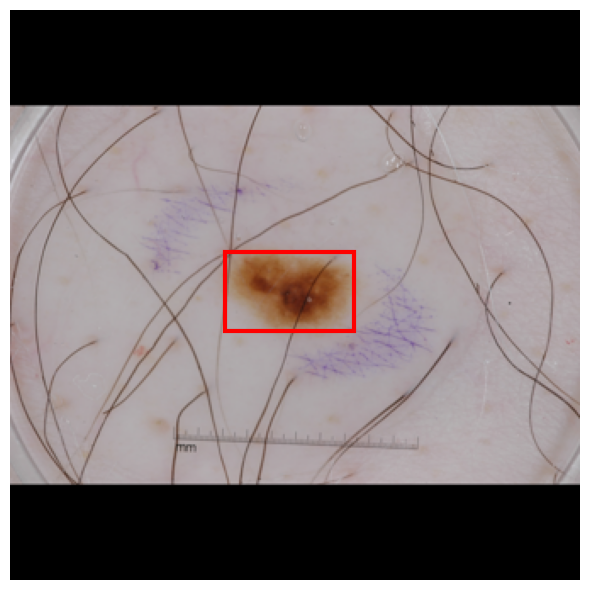

In [23]:
bboxes = sample["original_bboxes"]
assert len(bboxes) == 1
original_image = load_image(image_path)
image = expand2square(original_image, 0)
image = image.resize((336, 336))
bbox = convert_bbox_after_padding_and_resize(bboxes[0], original_image.size, resized_size=(336, 336))
print(sample["question"])
name = f"{dataset}_{subset}_{qs_num}"
folder = "./huatuo7b_samples"
thickness = 3
draw_bboxes(image, [bbox], name, thickness, folder)

In [ ]:
with open(os.path.join(folder, name, "question.txt"), "w") as file:
    file.write(sample["question"])
draw_att_map(sample["question"], image_path, layers, [bbox], name, thickness, folder)

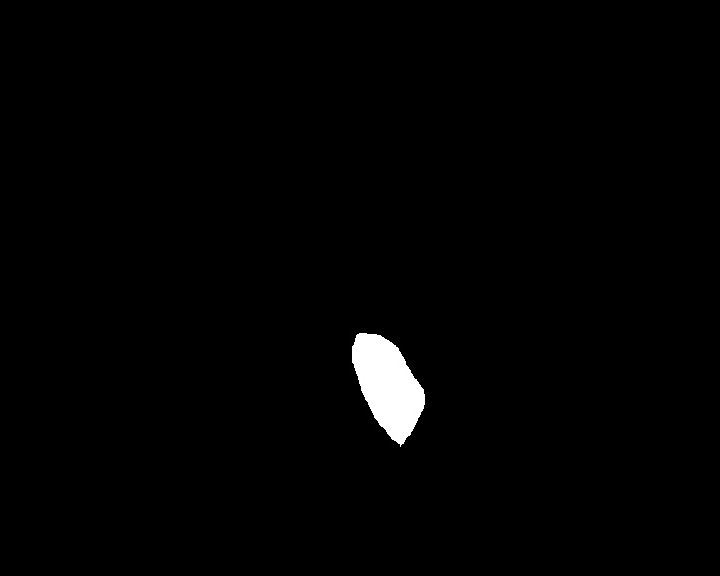

In [26]:
load_image(os.path.join(data_path, sample["mask"]))